In [7]:
import numpy as np
import pandas as pd

In [8]:
df=pd.read_csv('Salary_dataset.csv')

In [9]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [10]:
df=df.rename(columns={'Unnamed: 0':'index'})

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
lr=LinearRegression()

In [13]:
lr.fit(X=df[['YearsExperience']],y=df['Salary'])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9449.96]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.485e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [14]:
print(f'{lr.intercept_}\n{lr.coef_}\n')

24848.203966523193
[9449.96232146]



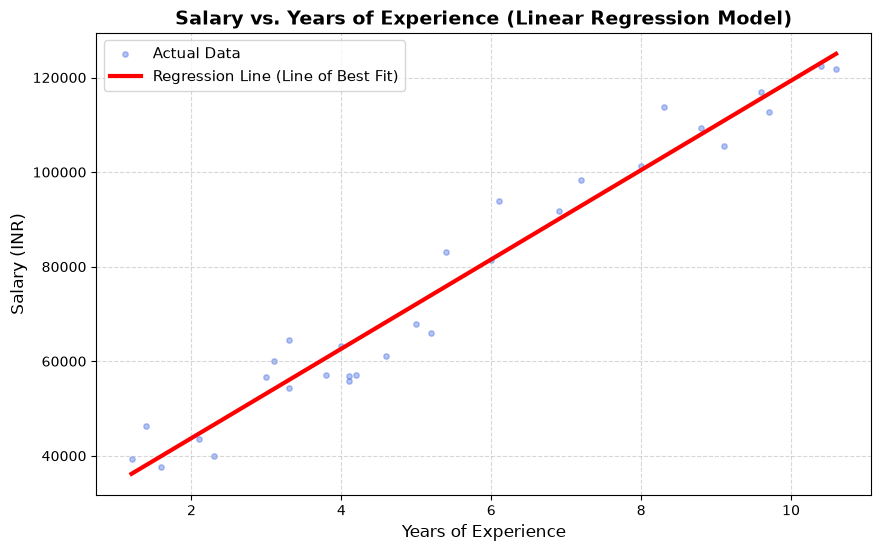

In [15]:
y_pred =lr.predict(df[['YearsExperience']])
plt.figure(figsize=(10, 6))
plt.scatter(df['YearsExperience'], df['Salary'], color='royalblue', alpha=0.4, s=15, label='Actual Data')
plt.plot(df['YearsExperience'], y_pred, color='red', linewidth=3, label='Regression Line (Line of Best Fit)')
plt.title('Salary vs. Years of Experience (Linear Regression Model)', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary (INR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.show()

In [2]:


# Set seed for perfect reproducibility
np.random.seed(42)

# Generate 2,000 random experience data points between 1 and 20 years
years_experience = np.round(np.random.uniform(1, 20, 2000), 1)

# Linear logic: Base salary $30k, $5.5k increase per year, plus random variation
base_salary = 30000
slope = 5500
noise = np.random.normal(0, 8000, 2000)

salary = np.round(base_salary + slope * years_experience + noise, 2)

# Assemble dataframe
df = pd.DataFrame({
    'YearsExperience': years_experience,
    'Salary': salary
})

# Save to your local directory
df.to_csv('salary_2000_rows.csv', index=False)
print("Dataset created successfully with shape:", df.shape)


Dataset created successfully with shape: (2000, 2)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load data
df = pd.read_csv('salary_2000_rows.csv')
X = df[['YearsExperience']]
y = df['Salary']

# 2. Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and fit linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Evaluate performance
y_pred = model.predict(X_test)
print(f"Intercept (Base Salary): ${model.intercept_:.2f}")
print(f"Coefficient (Per Year Raise): ${model.coef_[0]:.2f}")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")


Intercept (Base Salary): $29440.13
Coefficient (Per Year Raise): $5554.01
R² Score: 0.9328


In [4]:
import matplotlib.pyplot as plt

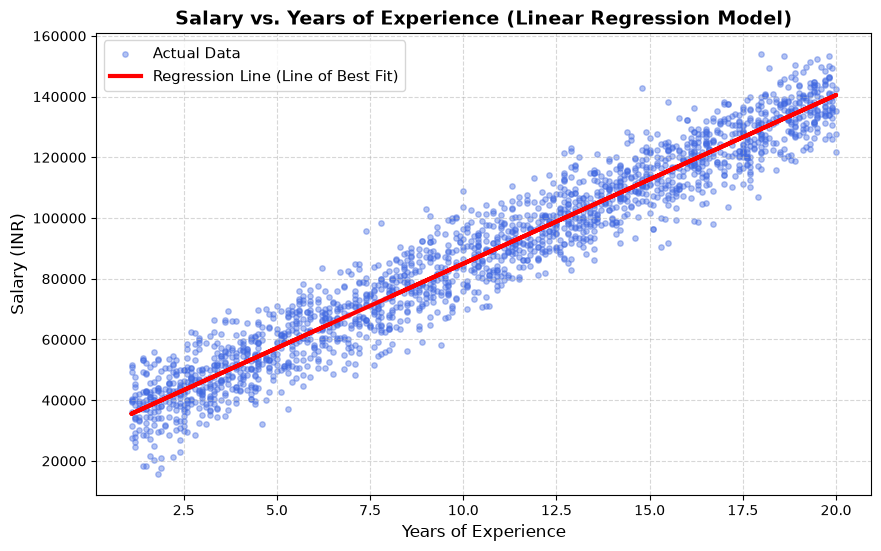

In [6]:
y_pred = model.predict(df[['YearsExperience']])
plt.figure(figsize=(10, 6))
plt.scatter(df['YearsExperience'], df['Salary'], color='royalblue', alpha=0.4, s=15, label='Actual Data')
plt.plot(df['YearsExperience'], y_pred, color='red', linewidth=3, label='Regression Line (Line of Best Fit)')
plt.title('Salary vs. Years of Experience (Linear Regression Model)', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary (INR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.show()

In [16]:
df=pd.read_csv('salary_2000_rows.csv')

In [20]:
x=df['YearsExperience'].to_numpy()
y=df['Salary'].to_numpy()

In [21]:
xbar=np.mean(x)
ybar=np.mean(y)

In [24]:
devx=x-xbar
devy=y-ybar

In [25]:
m=np.sum(devx*devy)/np.sum(devx**2)

In [29]:
c=ybar-xbar*m

In [30]:
xtest=np.array([6, 7], dtype=float)
pred=(m*xtest)+c
pred

array([62929.89068112, 68459.22996982])

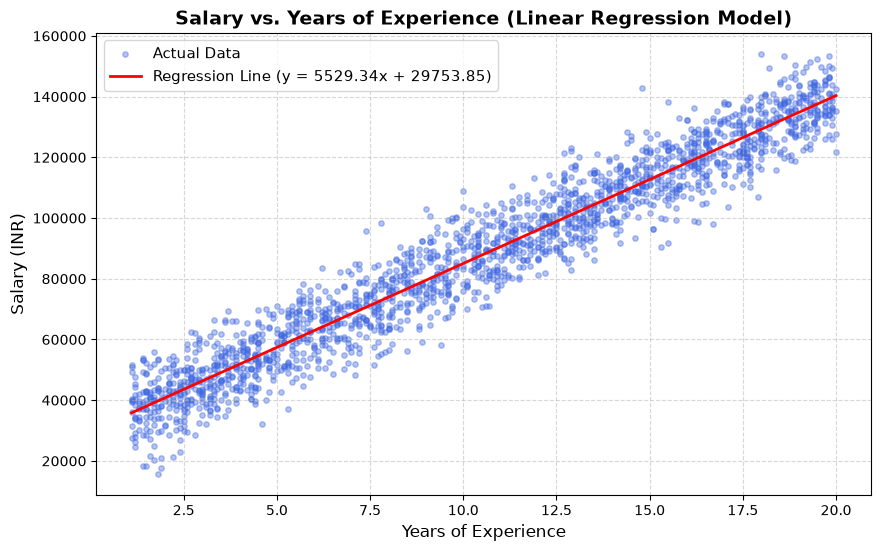

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='royalblue', alpha=0.4, s=15, label='Actual Data')
plt.plot(np.linspace(x.min(),x.max(),2000),(m*np.linspace(x.min(),x.max(),2000))+c,color='red',linewidth=2,label=f'Regression Line (y = {m:.2f}x + {c:.2f})')
plt.title('Salary vs. Years of Experience (Linear Regression Model)', fontsize=14, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary (INR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.show()

In [53]:
class SalaryPredictorGD:
    def __init__(self, learning_rate=0.01, epochs=2000):
        self.lr = learning_rate
        self.epochs = epochs
        self.m = 0.0
        self.c = 0.0
        self.x_mean, self.x_std = None, None

    def fit(self, x, y):
        n = len(x)
        self.x_mean = np.mean(x)
        self.x_std = np.std(x)
        x_scaled = (x - self.x_mean) / self.x_std
        for epoch in range(self.epochs):
            y_pred = (self.m * x_scaled) + self.c
            dm = (-2 / n) * np.sum(x_scaled * (y - y_pred))
            dc = (-2 / n) * np.sum(y - y_pred)
            self.m -= self.lr * dm
            self.c -= self.lr * dc
            if epoch % (self.epochs // 5) == 0:
                mse = (1 / n) * np.sum((y - y_pred) ** 2)
                print(f"Epoch {epoch:4d} | Cost (MSE): {mse:,.2f} | Intercept (c): {self.c:,.2f}")

    def predict(self, x):
        x_scaled = (x - self.x_mean) / self.x_std
        return (self.m * x_scaled) + self.c

    def plotline(self,x,y):
        plt.figure(figsize=(10, 6))
        plt.scatter(x, y, color='royalblue', alpha=0.4, s=15, label='Actual Data')
        x_line = np.linspace(x.min(), x.max(), 500)
        y_line = self.predict(x_line)
        plt.plot(x_line, y_line, color='#e74c3c', linewidth=3, label='Gradient Descent Line')
        plt.title('Salary vs. Years of Experience (Linear Regression Model)', fontsize=14, fontweight='bold')
        plt.xlabel('Years of Experience', fontsize=12)
        plt.ylabel('Salary (INR)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(fontsize=11)
        plt.show()

In [54]:
gdlr=SalaryPredictorGD()

In [55]:
gdlr.fit(x,y)

Epoch    0 | Cost (MSE): 8,691,356,939.78 | Intercept (c): 1,753.32
Epoch  400 | Cost (MSE): 64,029,412.36 | Intercept (c): 87,639.64
Epoch  800 | Cost (MSE): 64,028,586.83 | Intercept (c): 87,666.21
Epoch 1200 | Cost (MSE): 64,028,586.83 | Intercept (c): 87,666.22
Epoch 1600 | Cost (MSE): 64,028,586.83 | Intercept (c): 87,666.22


In [56]:
r2_score(y[1990:2000],gdlr.predict(x[1990:2000]))

0.9519016724692129

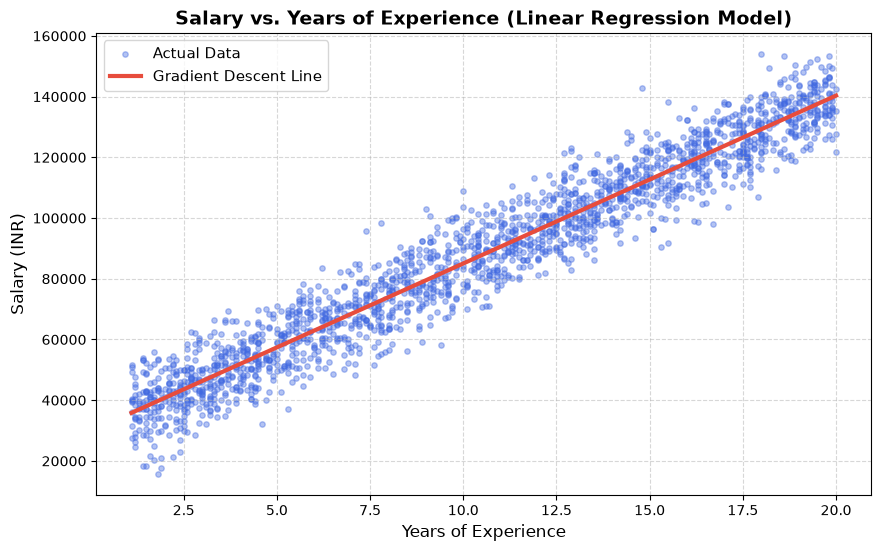

In [57]:
gdlr.plotline(x,y)